In [ ]:
## Logistic Regression

In [ ]:
# ==========================================
# Libraries + Spark Session
# ==========================================

from pyspark.sql import SparkSession
from pyspark.sql.functions import col

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import (
    MulticlassClassificationEvaluator,
    BinaryClassificationEvaluator
)

import matplotlib.pyplot as plt
import pandas as pd

spark = SparkSession.builder \
    .appName("Loan_Logistic_Regression_Model") \
    .getOrCreate()

print("Spark Session Created Successfully")

Spark Session Created Successfully


In [ ]:
# FULL PROFESSIONAL PREPROCESSING
# ==========================================

from pyspark.ml.feature import (
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    Imputer
)
from pyspark.ml import Pipeline

# ===============================
# Handle existing 'label' and 'features' columns for re-runs
# ===============================
# The current df state already has 'label' and 'features' columns, and 'Loan_Status' is gone.
# We assume 'label' is already the target column from previous steps.

# Drop 'features' column if it already exists to prevent error on rerun
if "features" in df.columns:
    df = df.drop("features")

# The 'Loan_Status' column does not exist in the current DataFrame, as it was likely
# renamed to 'label' in a previous execution. So, we'll remove this redundant line.
# df = df.withColumnRenamed("Loan_Status", "label")

# ===============================
#  Define Columns
# ===============================

numeric_cols = [
    "Age",
    "Income",
    "LoanAmount",
    "Credit_Score",
    "Employment_Years",
    "Credit_History",
    "Has_Defaulted",
    "Dependents"
]

categorical_cols = [
    "Gender",
    "Education_Level",
    "Married",
    "Job_Type",
    "Property_Area"
]

# ===============================
#  Handle Missing Numeric Values
# ===============================

imputer = Imputer(
    inputCols=numeric_cols,
    outputCols=numeric_cols
)

# ===============================
# Encode Categorical Columns
# ===============================
# NOTE: If categorical columns (e.g., 'Gender') in 'df' are already numeric (DoubleType)
# due to previous preprocessing (e.g., cell 'qaPmZZ0vFI5m'), the StringIndexer below
# will fail as it expects StringType. This pipeline is designed to work on raw
# categorical columns of StringType. To fully fix this, you would either need to
# reset 'df' to its raw state (e.g., by re-running the data loading cell) or modify
# the pipeline to handle already numeric categorical columns.

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=col + "_index",
        handleInvalid="keep"   # IMPORTANT: no record loss
    )
    for col in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=col + "_index",
        outputCol=col + "_encoded"
    )
    for col in categorical_cols
]

# ===============================
#  Assemble Final Features
# ===============================

encoded_cols = [col + "_encoded" for col in categorical_cols]

assembler = VectorAssembler(
    inputCols=numeric_cols + encoded_cols,
    outputCol="features",
    handleInvalid="keep"
)

# ===============================
#  Build Pipeline
# ===============================

pipeline = Pipeline(stages=[imputer] + indexers + encoders + [assembler])

pipeline_model = pipeline.fit(df)

df_final = pipeline_model.transform(df)

print("Preprocessing Complete Successfully")
print("Total Rows After Processing:", df_final.count())

Preprocessing Complete Successfully
Total Rows After Processing: 789396


In [ ]:
# ===============================
#  Train/Test Split
# ===============================

train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=42)

print("Train Count:", train_data.count())
print("Test Count:", test_data.count())

Train Count: 631384
Test Count: 158012


In [ ]:
# ===============================
# Logistic Regression Definition
# ===============================

from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    featuresCol="features",
    labelCol="label",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.0
)

print("Logistic Regression Model Initialized")

Logistic Regression Model Initialized


In [ ]:
# ===============================
# Training
# ===============================

model = lr.fit(train_data)

print("Training Complete")

Training Complete


In [ ]:
# ===============================
#Prediction
# ===============================

predictions = model.transform(test_data)

print("Prediction Complete")

predictions.select("label", "prediction", "probability").show(10)

Prediction Complete
+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    0|       0.0|[0.99734491937174...|
|    0|       0.0|[0.96744018788712...|
|    0|       0.0|[0.99621150119627...|
|    0|       0.0|[0.97606706606861...|
|    0|       0.0|[0.99471258187162...|
|    0|       0.0|[0.96806158703750...|
|    0|       0.0|[0.99671864122483...|
|    0|       0.0|[0.99005726441794...|
|    0|       0.0|[0.87234496793365...|
|    0|       0.0|[0.97916818719078...|
+-----+----------+--------------------+
only showing top 10 rows


In [ ]:
# ===============================
# Accuracy
# ===============================

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = accuracy_evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8217350580968534


In [ ]:
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

f1 = f1_evaluator.evaluate(predictions)

print("F1 Score:", f1)

F1 Score: 0.8201680712213292


In [ ]:
precision_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedPrecision"
)

precision = precision_evaluator.evaluate(predictions)

print("Precision:", precision)

Precision: 0.8207821097967478


In [ ]:
recall_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="weightedRecall"
)

recall = recall_evaluator.evaluate(predictions)

print("Recall:", recall)

Recall: 0.8217350580968534


In [ ]:
# ===============================
# AUC
# ===============================

from pyspark.ml.evaluation import BinaryClassificationEvaluator

auc_evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = auc_evaluator.evaluate(predictions)

print("AUC:", auc)

AUC: 0.8989321902397184


In [ ]:
print("====== FINAL EVALUATION ======")
print("Accuracy :", accuracy)
print("F1 Score :", f1)
print("Precision:", precision)
print("Recall   :", recall)
print("AUC      :", auc)

====== FINAL EVALUATION ======
Accuracy : 0.8217350580968534
F1 Score : 0.8201680712213292
Precision: 0.8207821097967478
Recall   : 0.8217350580968534
AUC      : 0.8989321902397184


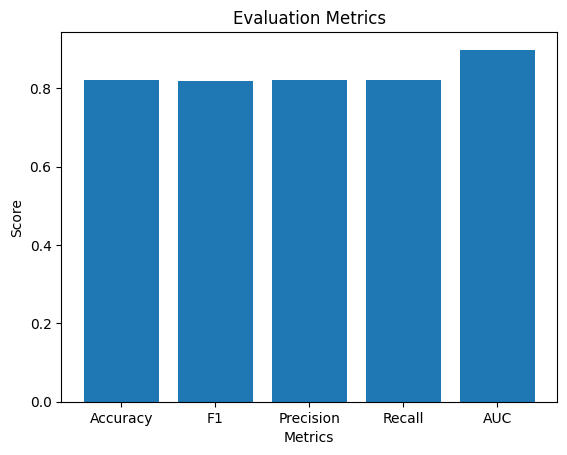

In [ ]:
# ===============================
#  Evaluation Visualization
# ===============================

import matplotlib.pyplot as plt

metrics = ["Accuracy", "F1", "Precision", "Recall", "AUC"]
scores = [accuracy, f1, precision, recall, auc]

plt.figure()
plt.bar(metrics, scores)
plt.title("Evaluation Metrics")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.show()

In [ ]:
# ===============================
#  Confusion Matrix
# ===============================

conf_matrix = predictions.groupBy("label", "prediction").count()
conf_matrix.show()

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    1|       0.0|11274|
|    0|       0.0|46462|
|    1|       1.0|83382|
|    0|       1.0|16894|
+-----+----------+-----+



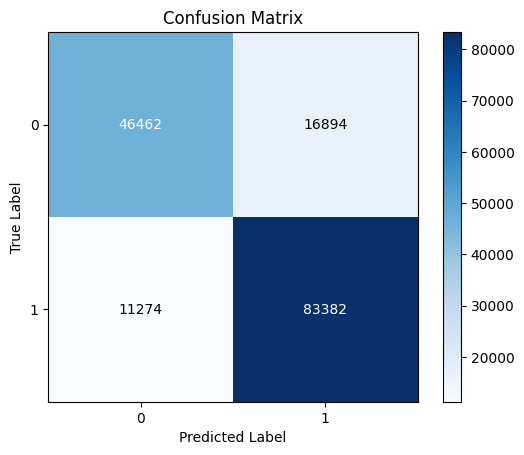

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Extract true labels and predictions from the Spark DataFrame
y_true = predictions.select("label").toPandas().squeeze()
y_pred = predictions.select("prediction").toPandas().squeeze()

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()

# Get unique classes from true labels
classes = np.unique(y_true)

plt.xticks(np.arange(len(classes)), classes)
plt.yticks(np.arange(len(classes)), classes)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j],
                 ha="center",
                 va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black") # Adjust text color for contrast

plt.show()

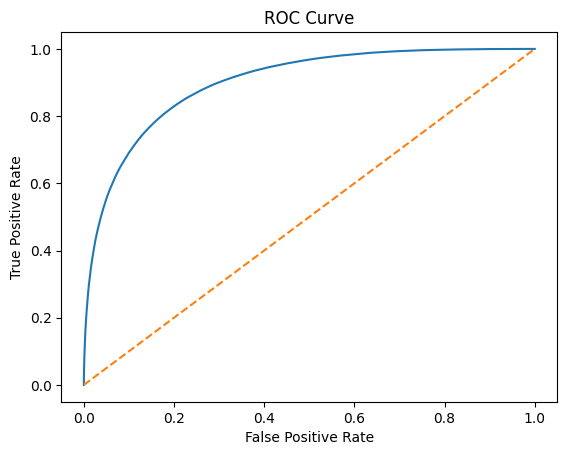

In [ ]:
#  ROC Curve
# ===============================

training_summary = model.summary
roc = training_summary.roc.toPandas()

plt.figure()
plt.plot(roc['FPR'], roc['TPR'])
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

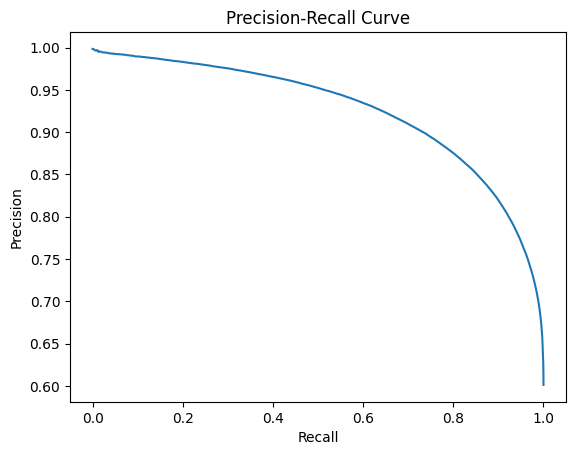

In [ ]:
pr = training_summary.pr.toPandas()

plt.figure()
plt.plot(pr['recall'], pr['precision'])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [ ]:
#  Feature Importance
# ===============================

import pandas as pd
from pyspark.ml.feature import StringIndexerModel, OneHotEncoderModel

coefficients = model.coefficients.toArray()

# --- Reconstruct feature names from pipeline metadata ---
feature_names_from_assembler = []

# Access the metadata of the 'features' column in df_final
# This metadata contains the actual names of the features that make up the vector
feature_metadata_attrs = df_final.schema['features'].metadata['ml_attr']['attrs']

# Iterate through different types of attributes (numeric, binary, nominal) that contribute to the vector
# The order here should match how VectorAssembler combines them implicitly
for attr_type in ['numeric', 'binary', 'nominal']:
    if attr_type in feature_metadata_attrs:
        for attr in feature_metadata_attrs[attr_type]:
            feature_names_from_assembler.append(attr['name'])

# Use the extracted names, or fallback to generic ones if something goes wrong
if len(feature_names_from_assembler) != len(coefficients):
    print(f"DEBUG: Mismatch in feature names length ({len(feature_names_from_assembler)}) and coefficients length ({len(coefficients)}).")
    # Fallback to generic names if metadata extraction is problematic
    all_features_for_importance = [f"feature_{i}" for i in range(len(coefficients))]
else:
    all_features_for_importance = feature_names_from_assembler

feature_importance = pd.DataFrame({
    "Feature": all_features_for_importance,
    "Coefficient": coefficients
})

feature_importance = feature_importance.sort_values(by="Coefficient", ascending=False)

print(feature_importance)

                        Feature  Coefficient
5                Credit_History     2.036304
19         Job_Type_encoded_0.0     0.776724
18         Job_Type_encoded_1.0     0.292061
12  Education_Level_encoded_2.0     0.277467
15          Married_encoded_0.0     0.248342
23    Property_Area_encoded_1.0     0.205401
8            Gender_encoded_1.0     0.073839
17          Married_encoded_2.0     0.049559
4              Employment_Years     0.048921
22         Job_Type_encoded_4.0     0.047147
10           Gender_encoded_2.0     0.033213
14  Education_Level_encoded_3.0     0.014899
0                           Age     0.012588
3                  Credit_Score     0.005508
1                        Income     0.000022
2                    LoanAmount    -0.000007
26    Property_Area_encoded_3.0    -0.038695
24    Property_Area_encoded_2.0    -0.061074
9            Gender_encoded_0.0    -0.091141
11  Education_Level_encoded_1.0    -0.119071
7                    Dependents    -0.166499
25    Prop

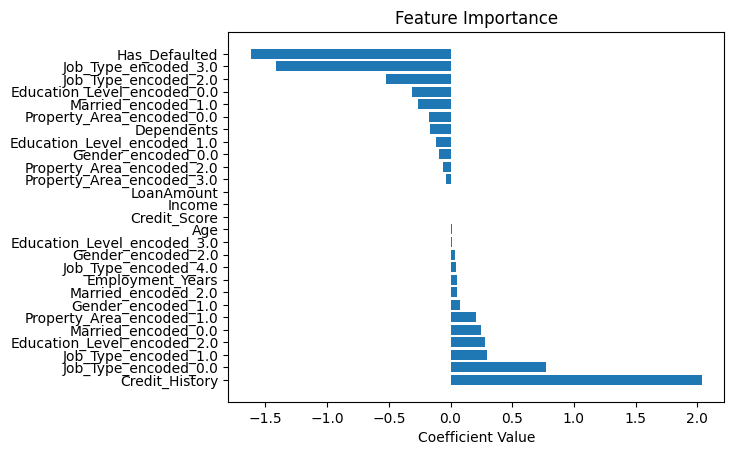

In [ ]:
plt.figure()
plt.barh(feature_importance["Feature"], feature_importance["Coefficient"])
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()

In [ ]:
# ===============================
#  Save Model
# ===============================

model.save("spark_logistic_model")

print("Model Saved Successfully")

Model Saved Successfully
